In [16]:
import re
import os
import pytesseract
from PIL import Image
from rapidfuzz import fuzz
import matplotlib.pyplot as plt

In [17]:
# List of available languages
print(pytesseract.get_languages(config=""))

['eng', 'osd', 'tha']


## Prototype


In [18]:
prefix = "."
folder_path = os.path.join(prefix, "images", "instructor")

# Extract image files
image_file_paths = []
for file in os.listdir(folder_path):
    file_lower = file.lower()
    if (
        file_lower.endswith(".jpg")
        or file_lower.endswith(".png")
        or file_lower.endswith(".jpeg")
    ):
        image_file_paths.append(os.path.join(folder_path, file))
print("Image files found:", image_file_paths)

Image files found: ['.\\images\\instructor\\2_SURADIT SUKSAP.png', '.\\images\\instructor\\60b285aa-a5e3-4901-a997-6204f135013a_NATTANICHA TIPNET.jpg', '.\\images\\instructor\\650610367-ประเมินอาจารย์ผู้สอน_CHANUNRAT NOK-IN.PNG', '.\\images\\instructor\\650610404 ประเมินอาจารย์_THANRADA YEUNSUK.JPG', '.\\images\\instructor\\Capture1_NATTANICHA TIBPALA.PNG', '.\\images\\instructor\\Capture2_PARAMA WILAIWAN.PNG', '.\\images\\instructor\\gg2_TANUSORN AINTARAPU.JPG', '.\\images\\instructor\\messageImage_1762226387208_THAWANRAT SAENASUTTI.jpg', '.\\images\\instructor\\Screenshot (10)_CHUTINAN SUMPAWO.png', '.\\images\\instructor\\Screenshot (2)_SURACHET WICHA.png', '.\\images\\instructor\\Screenshot 2025-11-03 133452_TAYAGORN PRATHUMPITA.png', '.\\images\\instructor\\Screenshot 2025-11-03 133856_NICHA MALIWAN.png', '.\\images\\instructor\\Screenshot 2025-11-03 134642_JETSADA PHAISON.png', '.\\images\\instructor\\Screenshot 2025-11-03 135201_KALANYUTA WORAPHATWI.png', '.\\images\\instructor\

Processed OCR Output:
” 6@ 0หปเ๐อท % | /โ พิทธ!โเธ๓ 7% | () กิทธ|-ซเอยเฮท- % | พซี๊ คิทธ1255441 - % | ผ@ ๒โห๒๐โท และ8๒ % โปี่ มือนเรอภิรรอรร % โร ธ์พิ0-20 โอ๒๓๓ % | ดร ธ์ด-20 โอ๒๓๓ % | - * - 5ร.๕ททน.ธ6ข่า/๕ทานรไร/ซิหธนธิอทโรล6ท/(6อนกรอ/เรรสรร?ธุ๑=(6อนกรอ/เธรธรร เล ก @ : ฮี ว เ โห|[สผด @ ทาะเบียนประวัติ "' = ประเมินการเรียนการสอน จ] ข่าวกิจกรรม 2 ประเมินการสอน จุ .@ ประเมินกระบวนวิชา ซ# ประเมินผู้สอน ระบบจัดหางาน ว วิชาที่ " รายชื่อกระบวนวิชาที่ลงทะเบียนสอน โ ระบบทุนการศึกษา 'พบรายการทั้งสิ้น 5 รายการ เด บเทเทศ รหัสกระบวนวิชา ชื่อกระบวนวิชา ตอนบรรยาย 'ตอนปฏิบัติการ ประเภทกระบวนวิชา. สถานะการประเมิน โก " 255439 [| 7ฏ275 +' 001 000 บรรยาย (!@๕9) |] กิจกรรมสาธารณประโยชน์ 255441 แกโ็อทฑาลผ่อท โฮอําทอ!อธูเ โอก !ทต่นรแทล| อิทธิกล๑ก5 001 000 บรรยาย (!@๕๕๒6@) / ประเมินแล้ว % ระบบกิจกรรมนักศึกษา “” 255447 กลั่นรแทอ| ศิอ๒อน์๐ร สทส /เห์กิตร! กไอ!ไซอท๐๑ /เวอไรน่อกร 001 000 บรรยาย (!@๕๕๒6@) @ บริการสําหรับนักศึกษา “” 951100 1หอส่อกท มท็ ฮกส์ /เทโทารนอก. 001 000 บบรรยาย (!.@๕๒๑@) « 953111 รอโณพลทอ กอ

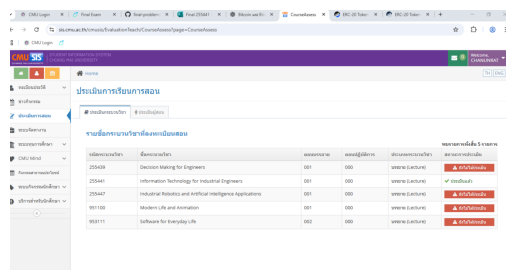

In [19]:
filepath = image_file_paths[2]  # Use the first image file for processing

language = "tha"
matching_texts = [
    "255441",
    "นิรันดร์",
    "พิสุทธอานนท์",
    "ประเมินแล้ว",
]


# language = "eng"
# matching_texts = [
#     "255441",
#     "Nirand",
#     "Pisutha-Arnond",
# ]

_text = pytesseract.image_to_string(Image.open(filepath), lang=language).strip()
# print("Raw OCR Output:")
# print(_text)
# Remove multiple whitespaces
text = re.sub(r"\s+", " ", _text)
# Remove line breaks
text = re.sub(r"\n+", " ", text)
print("Processed OCR Output:")
print(text)

# process.extract("นิรันดร์ พิสุทธอานนท์", [text_th], scorer=fuzz.partial_ratio)
for matching_text in matching_texts:
    score = fuzz.partial_ratio(matching_text, text)
    print(f"Matching '{matching_text}' with OCR output: {score}%")

plt.imshow(Image.open(filepath))
plt.axis("off")
plt.show()

In [22]:
def evaluate_ocr(filepath, language, matching_texts):
    _text = pytesseract.image_to_string(Image.open(filepath), lang=language).strip()
    text = re.sub(r"\s+", " ", _text)
    text = re.sub(r"\n+", " ", text)

    scores = []
    for matching_text in matching_texts:
        score = fuzz.partial_ratio(matching_text, text)
        scores.append(dict(matching_text=matching_text, score=score))
    return dict(
        scores=scores,
        ocr_text=text,
        filepath=filepath,
        language=language,
    )

In [23]:
result_arr = []
for image_file_path in image_file_paths:
    result = evaluate_ocr(image_file_path, language, matching_texts)
    result_arr.append(result)
    for score_info in result["scores"]:
        print(f"  Matching '{score_info['matching_text']}': {score_info['score']}%")
    print(f"  OCR Text: {result['ocr_text']}\n")

  Matching '255441': 100.0%
  Matching 'นิรันดร์': 75.0%
  Matching 'พิสุทธอานนท์': 100.0%
  Matching 'ประเมินแล้ว': 100.0%
  OCR Text: .@ ประเมินกระบวนวิชา | ซ# ประเมินผู้สอน รายชื่อกระบวนวิชาที่ลงทะเบียนสอน 'พบรายการทั้งสิ้น 7 รายการ รหัสกระบวน " ชื่อผ้ง ตอน ตอนปฏิบัติ ประเภทกระบวน " ว ซื่อกระบวนวิชา ชื่อผู้สอน " สถานะการประเมิน วิชา บรรยาย การ วิชา 255320 อิทธูเทออท์ทธ 0อ๑กรปิอท สิดรอลกะท ชมพูนุท เกษมเศรษฐ์ (๐011000ผ001 002 000 บรรยาย (๑๓๒6๐ |รๆ ระเเรรๆ 255320 อิทธูเทออท์ทธ 0อ6กรปิอท สิดรอลกะท ชวิศ บุญมี (6หล15 80อมพเหธธ) 002 000 บรรยาย (1๕๑) 255321 เกล่บระท่ด| ซิทธูเกรอท์ทธิ ดูนรนญ 6อกเอ! รุ่งฉัตร ชมภูอินไหว (ตุปพ๕6หล ๕4๐เอป- 002 000 บรรยาย (1๕๑) เพพล) 255321 เกล่นระท่ด| ซิทธูเกรอท์ทธิ ดูนรไญ 6อกเอ! วาปี มโนภินิเวศ (ห/65ธ5 ง1ล08เพเพธร) 002 000 บรรยาย (๑๓๒6๐ [ๆ 255441 แกร็อทกทรน่อท โลอททอเอดู/ โอ/ เทต่นระทร| นิธันตร์ พิสุทธอานนท์ (ผเฒเงว อเรบาห่ละ 001 000 บรรยาย (!@๕บ@) จ” ประเมินแล้ว อทธูเทอรกร สผอม9) 255447 แทต่นระท่ธ!| พิอ๒๐ข์ร ธกส #เญ์กิ6เธ| !ทรอ!ไซรก๕๐ อรรถพล สมุทคุปดี์ (ป7650!

In [30]:
process_arr = []
for result in result_arr:
    for score_info in result["scores"]:
        mean_score = sum(score_info["score"] for score_info in result["scores"]) / len(result["scores"])
        # print(f"  Matching '{score_info['matching_text']}': {score_info['score']}%")
    process_arr.append(dict(mean_score=mean_score, **result))

Low OCR quality for .\images\instructor\650610367-ประเมินอาจารย์ผู้สอน_CHANUNRAT NOK-IN.PNG (Mean Score: 72.91666666666667%)


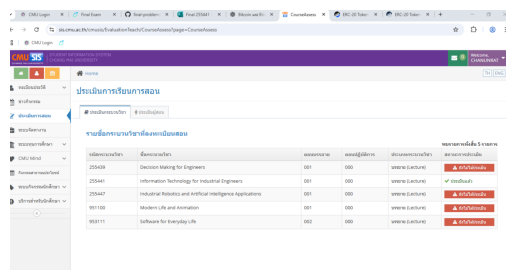

Low OCR quality for .\images\instructor\gg2_TANUSORN AINTARAPU.JPG (Mean Score: 65.0%)


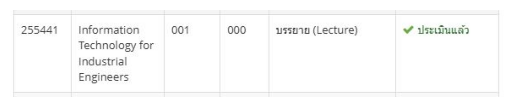

Low OCR quality for .\images\instructor\Screenshot (2)_SURACHET WICHA.png (Mean Score: 71.875%)


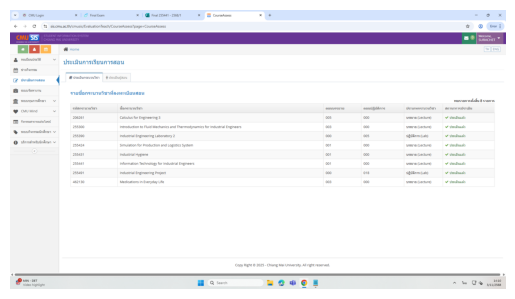

Low OCR quality for .\images\instructor\ประเมินอาจารย์_NINNAT KLAROB.PNG (Mean Score: 0.0%)


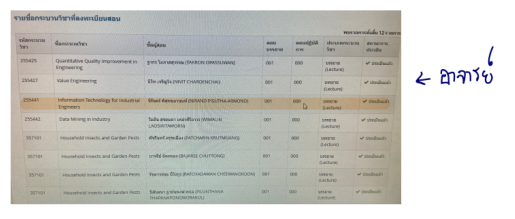

In [37]:
for result in process_arr:
    if result["mean_score"] < 75:
        print(f"Low OCR quality for {result['filepath']} (Mean Score: {result['mean_score']}%)")
        plt.imshow(Image.open(result["filepath"]))
        plt.axis("off")
        plt.show()